In [1]:
from typing import Union
import pandas as pd
import numpy as np

import pymc as pm
import pymc.sampling.jax as pmjax
import pytensor.tensor as pt
import arviz as az
import arviz_stats as azs
import arviz_plots as azp
import xarray as xr

import matplotlib.pyplot as plt

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
print("arviz: "+az.__version__)

pandas: 3.0.1
numpy: 2.4.3
pymc: 6.2.0
arviz: 1.2.0


In [2]:
df = pd.read_csv('data/projection_data.csv')
df.head(10)

,player_full_id,SEASON,shot_type,PLAYER_ID,PLAYER,player_age,age_z,HEIGHT_INCHES,height_z,birthdate,posit,attempts,actual_makes,expected_makes,offset
0,A.J. Lawson (1630639),2022-23,DUNK,1630639.0,A.J. Lawson,23.041752,-1.047506,78.0,-0.203215,2000-07-15,G,6,5,4.606923,1.196045
1,A.J. Lawson (1630639),2022-23,JUMPER,1630639.0,A.J. Lawson,23.041752,-1.047506,78.0,-0.203215,2000-07-15,G,27,12,10.200240,-0.498953
2,A.J. Lawson (1630639),2022-23,LAYUP,1630639.0,A.J. Lawson,23.041752,-1.047506,78.0,-0.203215,2000-07-15,G,11,5,6.662227,0.429093
3,A.J. Lawson (1630639),2023-24,DUNK,1630639.0,A.J. Lawson,24.043806,-0.804040,78.0,-0.203215,2000-07-15,G,13,12,9.504221,1.000180
4,A.J. Lawson (1630639),2023-24,JUMPER,1630639.0,A.J. Lawson,24.043806,-0.804040,78.0,-0.203215,2000-07-15,G,62,15,23.988975,-0.460282
5,A.J. Lawson (1630639),2023-24,LAYUP,1630639.0,A.J. Lawson,24.043806,-0.804040,78.0,-0.203215,2000-07-15,G,46,27,28.212996,0.461315
6,A.J. Lawson (1630639),2024-25,DUNK,1630639.0,A.J. Lawson,25.043121,-0.561239,78.0,-0.203215,2000-07-15,G,14,11,9.627423,0.789263
7,A.J. Lawson (1630639),2024-25,JUMPER,1630639.0,A.J. Lawson,25.043121,-0.561239,78.0,-0.203215,2000-07-15,G,106,33,39.452497,-0.522819
8,A.J. Lawson (1630639),2024-25,LAYUP,1630639.0,A.J. Lawson,25.043121,-0.561239,78.0,-0.203215,2000-07-15,G,70,36,41.499993,0.375789
9,A.J. Lawson (1630639),2025-26,DUNK,1630639.0,A.J. Lawson,26.042437,-0.318437,78.0,-0.203215,2000-07-15,G,4,3,2.848839,0.906141


In [3]:
test = df.loc[df['SEASON'].isin(['2025-26'])].reset_index(drop=True)
df = df.loc[~df['SEASON'].isin(['2025-26'])].reset_index(drop=True)

In [4]:
df.shape

(26576, 15)

In [5]:
len(df['player_full_id'].unique())

1657

In [6]:
def define_index(data: pd.DataFrame, label: str) -> Union[np.array, dict]:
    """Defines an index variable starting at 0. 
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values
    return index_vals, lookup

In [7]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pmjax.sample_numpyro_nuts(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        xr.DataTree.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [8]:
df["player_idx"], player_lookup = define_index(df, "player_full_id")
player_idx_vals = df['player_idx'].values.astype("int32")
n_obs = len(df)

df['season_idx'], season_lookup = define_index(df, "SEASON")
season_idx_vals = df['season_idx'].values.astype("int32")

df['shot_type_idx'], shot_type_lookup = define_index(df, "shot_type")
shot_type_idx_vals = df['shot_type_idx'].values.astype("int32")

df['position_idx'], position_lookup = define_index(df, "posit")
position_idx_vals = df['position_idx'].values.astype("int32")

target = df['actual_makes'].values
offset_vals = df['offset'].values
age_z_vals = df['age_z'].values
height_z_vals = df['height_z'].values
attempts_vals = df['attempts'].values
expected_makes_vals = df['expected_makes'].values

In [9]:
season_list = sorted(df['SEASON'].unique())
season_list

['2010-11',
 '2011-12',
 '2012-13',
 '2013-14',
 '2014-15',
 '2015-16',
 '2016-17',
 '2017-18',
 '2018-19',
 '2019-20',
 '2020-21',
 '2021-22',
 '2022-23',
 '2023-24',
 '2024-25']

In [ ]:
coords = {
    "obs_id": np.arange(len(target)),
    "shot_type":shot_type_lookup.keys(),
    "player": player_lookup.keys(),
    "season": season_list,
    }
n_shot_types = len(shot_type_lookup.keys())
n_seasons = len(coords["season"])

with pm.Model(coords=coords) as model:
    shots_made = pm.Data("shots_made", target, dims=("obs_id",))
    offset_data = pm.Data("offset_data", offset_vals, dims=("obs_id",))
    attempts_data = pm.Data("attempts_data", attempts_vals, dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("obs_id",))
    season_idx = pm.Data("season_idx", season_idx_vals, dims=("obs_id",))
    shot_type_idx = pm.Data("shot_type_idx", shot_type_idx_vals, dims=("obs_id",))

    # baseline
    offset_weight = pm.Normal("offset_weight", mu=0.2, sigma=0.2, dims=("shot_type",))
    shot_type_intercept = pm.Normal("shot_type_intercept", mu=0, sigma=1, dims=("shot_type",))
    # career skill
    player_st_dev = pm.HalfNormal("player_st_dev", 0.5, dims=("shot_type",))
    z_mu = pm.Normal("z_mu", mu=0, sigma=1, dims=("shot_type", "player"))
    mu = pm.Deterministic("mu", z_mu.T * player_st_dev[None, :], dims=("player", "shot_type"))
    # seasonal component
    sigma_dev = pm.Exponential("sigma_dev", 1.0, dims="shot_type") # season deviation
    delta_raw = pm.ZeroSumNormal(
        "delta_raw",
        sigma=1.0,
        dims=("player", "shot_type", "season"),
        n_zerosum_axes=1
    )
    delta = pm.Deterministic(
        "delta",
        delta_raw * sigma_dev[None, :, None],
        dims=("player", "shot_type", "season")
    )
    skill_grid = mu[:, :, None] + delta
    skill_obs = skill_grid[player_idx, shot_type_idx, season_idx]
    
    theta = (
        offset_weight[shot_type_idx] * offset_data
        + shot_type_intercept[shot_type_idx]
        + skill_obs
    )
    pm.Binomial("obs", n=attempts_data, p=pm.math.sigmoid(theta), observed=shots_made)

In [47]:
trace = sample(model, tune=1000, draws=1000, target_accept=0.9, dense_mass=True)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [48]:
azs.summary(trace, var_names=["offset_weight", "shot_type_intercept", "player_st_dev", "sigma_dev"], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
offset_weight[DUNK],0.35,0.03,0.29,0.40,3102.33,3071.59,1.00,0.0,0.0
offset_weight[JUMPER],0.21,0.04,0.13,0.29,1407.41,2108.87,1.00,0.0,0.0
offset_weight[LAYUP],0.11,0.02,0.08,0.15,2781.55,2780.91,1.00,0.0,0.0
offset_weight[HOOK],0.17,0.07,0.03,0.31,4751.36,2909.74,1.00,0.0,0.0
shot_type_intercept[DUNK],1.72,0.04,1.65,1.79,2433.04,2794.22,1.00,0.0,0.0
shot_type_intercept[JUMPER],-0.49,0.02,-0.52,-0.45,1308.38,1971.09,1.00,0.0,0.0
shot_type_intercept[LAYUP],0.13,0.01,0.11,0.16,2312.91,2425.23,1.00,0.0,0.0
shot_type_intercept[HOOK],-0.11,0.01,-0.14,-0.08,2500.52,2905.48,1.00,0.0,0.0
player_st_dev[DUNK],0.38,0.02,0.35,0.41,1244.47,2046.69,1.00,0.0,0.0
player_st_dev[JUMPER],0.16,0.00,0.15,0.17,1047.90,1635.64,1.00,0.0,0.0


In [17]:
coords = {
    "obs_id": np.arange(len(target)),
    "shot_type":shot_type_lookup.keys(),
    "player": player_lookup.keys(),
    "season": season_list,
    }
n_shot_types = len(shot_type_lookup.keys())
n_seasons = len(coords["season"])

with pm.Model(coords=coords) as model_mvn:
    shots_made = pm.Data("shots_made", target, dims=("obs_id",))
    offset_data = pm.Data("offset_data", offset_vals, dims=("obs_id",))
    attempts_data = pm.Data("attempts_data", attempts_vals, dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("obs_id",))
    season_idx = pm.Data("season_idx", season_idx_vals, dims=("obs_id",))
    shot_type_idx = pm.Data("shot_type_idx", shot_type_idx_vals, dims=("obs_id",))

    # baseline
    offset_weight = pm.Normal("offset_weight", mu=0.2, sigma=0.2, dims=("shot_type",))
    shot_type_intercept = pm.Normal("shot_type_intercept", mu=0, sigma=1, dims=("shot_type",))
    # career skill
    chol, corr, stds = pm.LKJCholeskyCov("chol_shot_type", n=n_shot_types, eta=2.0, sd_dist=pm.HalfNormal.dist(0.25))
    mu = pm.MvNormal("mu", mu=pt.zeros(n_shot_types), chol=chol, dims=("player", "shot_type"))
    # seasonal component
    sigma_dev = pm.HalfNormal("sigma_dev", 0.25, dims="shot_type") # season deviation
    delta_raw = pm.ZeroSumNormal(
        "delta_raw",
        sigma=1.0,
        dims=("player", "shot_type", "season"),
        n_zerosum_axes=1
    )
    delta = pm.Deterministic(
        "delta",
        delta_raw * sigma_dev[None, :, None],
        dims=("player", "shot_type", "season")
    )
    skill_obs = mu[player_idx, shot_type_idx] + delta[player_idx, shot_type_idx, season_idx]
    
    theta = (
        offset_weight[shot_type_idx] * offset_data
        + shot_type_intercept[shot_type_idx]
        + skill_obs
    )
    pm.Binomial("obs", n=attempts_data, p=pm.math.sigmoid(theta), observed=shots_made)

In [18]:
trace_mvn = sample(model_mvn, tune=3000, draws=2000, target_accept=0.99, dense_mass=True, path='trace_mvn.nc')

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [19]:
azs.summary(trace_mvn, var_names=["offset_weight", "shot_type_intercept", "chol_shot_type","sigma_dev"], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
offset_weight[DUNK],0.33,0.03,0.27,0.39,7846.13,6672.79,1.00,0.0,0.0
offset_weight[JUMPER],0.13,0.04,0.05,0.21,3332.25,4524.53,1.00,0.0,0.0
offset_weight[LAYUP],0.13,0.02,0.09,0.16,4648.17,5698.31,1.00,0.0,0.0
offset_weight[HOOK],0.14,0.07,-0.00,0.29,10919.03,6624.66,1.00,0.0,0.0
shot_type_intercept[DUNK],1.73,0.04,1.65,1.80,6267.75,5980.43,1.00,0.0,0.0
shot_type_intercept[JUMPER],-0.53,0.02,-0.57,-0.49,2740.39,4132.92,1.00,0.0,0.0
shot_type_intercept[LAYUP],0.11,0.01,0.08,0.14,3177.15,4440.25,1.00,0.0,0.0
shot_type_intercept[HOOK],-0.14,0.02,-0.17,-0.11,3080.33,4874.49,1.00,0.0,0.0
chol_shot_type[0],0.38,0.02,0.35,0.41,1356.56,2391.72,1.01,0.0,0.0
chol_shot_type[1],0.02,0.01,0.00,0.03,2218.03,3550.07,1.00,0.0,0.0


In [20]:
az.summary(trace_mvn, var_names=["chol_shot_type_corr","chol_shot_type_stds"], ci_prob=0.95, round_to=2)

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"chol_shot_type_corr[0, 0]",1.00,0.00,1.00,1.00,8000.00,8000.00,NaN,0.0,NaN
"chol_shot_type_corr[0, 1]",0.12,0.05,0.03,0.22,2170.61,3418.84,1.00,0.0,0.0
"chol_shot_type_corr[0, 2]",0.47,0.04,0.38,0.55,1713.72,2696.65,1.00,0.0,0.0
"chol_shot_type_corr[0, 3]",0.29,0.07,0.15,0.43,409.28,964.94,1.02,0.0,0.0
"chol_shot_type_corr[1, 0]",0.12,0.05,0.03,0.22,2170.61,3418.84,1.00,0.0,0.0
"chol_shot_type_corr[1, 1]",1.00,0.00,1.00,1.00,7978.93,8000.00,1.00,0.0,0.0
"chol_shot_type_corr[1, 2]",0.50,0.03,0.43,0.56,3402.99,5374.39,1.00,0.0,0.0
"chol_shot_type_corr[1, 3]",0.30,0.06,0.19,0.41,1206.38,2315.19,1.00,0.0,0.0
"chol_shot_type_corr[2, 0]",0.47,0.04,0.38,0.55,1713.72,2696.65,1.00,0.0,0.0
"chol_shot_type_corr[2, 1]",0.50,0.03,0.43,0.56,3402.99,5374.39,1.00,0.0,0.0


In [21]:
corr = trace_mvn.posterior["chol_shot_type_corr"]
corr_mean = corr.mean(dim=["chain", "draw"]).values
pd.DataFrame(
    corr_mean,
    index=shot_type_lookup.keys(),
    columns=shot_type_lookup.keys()
)

,DUNK,JUMPER,LAYUP,HOOK
DUNK,1.000000,0.122559,0.471630,0.292701
JUMPER,0.122559,1.000000,0.499082,0.300710
LAYUP,0.471630,0.499082,1.000000,0.482206
HOOK,0.292701,0.300710,0.482206,1.000000


In [22]:
corr_05 = corr.quantile(0.05, dim=("chain", "draw")).values
corr_95 = corr.quantile(0.95, dim=("chain", "draw")).values
corr_05_df = pd.DataFrame(
    corr_05,
    index=shot_type_lookup.keys(),
    columns=shot_type_lookup.keys()
)
corr_95_df = pd.DataFrame(
    corr_95,
    index=shot_type_lookup.keys(),
    columns=shot_type_lookup.keys()
)

In [23]:
corr_05_df

,DUNK,JUMPER,LAYUP,HOOK
DUNK,1.000000,0.042556,0.398694,0.173751
JUMPER,0.042556,1.000000,0.446411,0.206025
LAYUP,0.398694,0.446411,1.000000,0.391732
HOOK,0.173751,0.206025,0.391732,1.000000


In [24]:
corr_95_df

,DUNK,JUMPER,LAYUP,HOOK
DUNK,1.000000,0.202362,0.541119,0.408424
JUMPER,0.202362,1.000000,0.550354,0.391786
LAYUP,0.541119,0.550354,1.000000,0.567472
HOOK,0.408424,0.391786,0.567472,1.000000


In [25]:
mu = trace_mvn.posterior["mu"]
mu_mean = mu.mean(dim=("chain", "draw"))

In [26]:
delta = trace_mvn.posterior["delta"]
delta_mean = delta.mean(dim=("chain", "draw"))

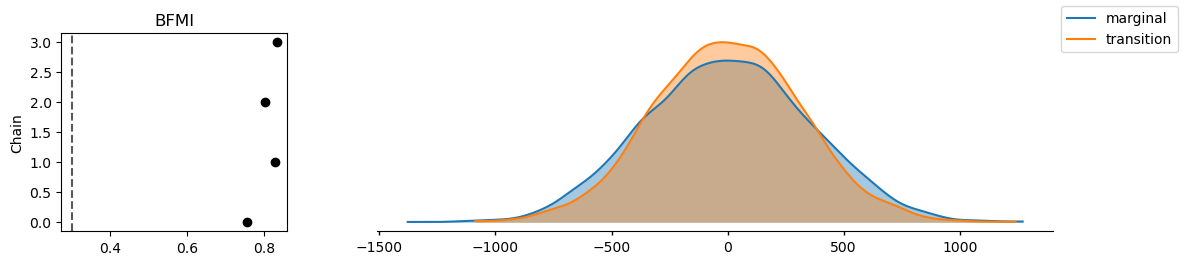

In [28]:
azp.plot_energy(trace_mvn)

In [29]:
spp = sample_posterior_pred(model_mvn, trace_mvn)

Sampling: [obs]


Output()

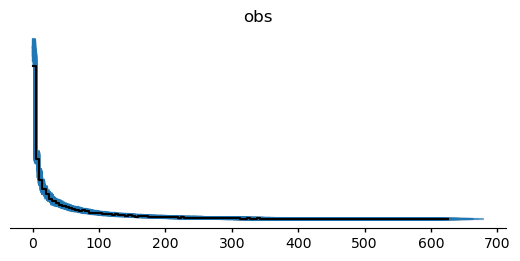

In [33]:
azp.plot_ppc_dist(spp, var_names="obs", num_samples=250)

In [10]:
df['player_age'].describe()

count    26576.000000
mean        27.106061
std          4.219903
min         19.583847
25%         23.904175
50%         26.372348
75%         29.839836
max         43.509925
Name: player_age, dtype: float64

In [12]:
coords = {
    "obs_id": np.arange(len(target)),
    "shot_type":shot_type_lookup.keys(),
    "shot_type_": shot_type_lookup.keys(),
    "player": player_lookup.keys(),
    "season": season_list,
    }
n_shot_types = len(shot_type_lookup.keys())
n_seasons = len(coords["season"])

with pm.Model(coords=coords) as model_quad:
    shots_made = pm.Data("shots_made", target, dims=("obs_id",))
    offset_data = pm.Data("offset_data", offset_vals, dims=("obs_id",))
    attempts_data = pm.Data("attempts_data", attempts_vals, dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("obs_id",))
    season_idx = pm.Data("season_idx", season_idx_vals, dims=("obs_id",))
    shot_type_idx = pm.Data("shot_type_idx", shot_type_idx_vals, dims=("obs_id",))
    age_data = pm.Data("age_z", age_z_values, dims=("obs_id",))

    # baseline
    offset_weight = pm.Normal("offset_weight", mu=0.2, sigma=0.2, dims=("shot_type",))
    shot_type_intercept = pm.Normal("shot_type_intercept", mu=0, sigma=1, dims=("shot_type",))
    # career skill
    chol, corr, stds = pm.LKJCholeskyCov("chol_shot_type", n=n_shot_types, eta=2.0, sd_dist=pm.HalfNormal.dist(0.25))
    pm.Deterministic("shot_type_corr", corr, dims=("shot_type", "shot_type_"))
    mu = pm.MvNormal("mu", mu=pt.zeros(n_shot_types), chol=chol, dims=("player", "shot_type"))
    # seasonal component
    sigma_dev = pm.HalfNormal("sigma_dev", 0.25, dims="shot_type") # season deviation
    delta_raw = pm.ZeroSumNormal(
        "delta_raw",
        sigma=1.0,
        dims=("player", "shot_type", "season"),
        n_zerosum_axes=1
    )
    delta = pm.Deterministic(
        "delta",
        delta_raw * sigma_dev[None, :, None],
        dims=("player", "shot_type", "season")
    )
    skill_obs = mu[player_idx, shot_type_idx] + delta[player_idx, shot_type_idx, season_idx]
    # age
    a = pm.Normal("a", mu=0, sigma=0.25, dims=("shot_type",))
    b = pm.Normal("b", mu=0, sigma=0.25, dims=("shot_type",))
    f = pm.Deterministic('f', a[shot_type_idx]*age_data**2 + b[shot_type_idx]*age_data)
    
    theta = (
        offset_weight[shot_type_idx] * offset_data
        + shot_type_intercept[shot_type_idx]
        + skill_obs
        + f
    )
    pm.Binomial("obs", n=attempts_data, p=pm.math.sigmoid(theta), observed=shots_made)

In [ ]:
trace_quad = sample(model_quad, tune=2000, draws=2000, target_accept=0.99, dense_mass=True, path='trace_quad.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [14]:
azs.summary(trace_quad, var_names=["offset_weight", "shot_type_intercept", "shot_type_corr", "a", "b"], ci_prob=0.95, round_to=2)

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
offset_weight[DUNK],0.34,0.03,0.28,0.40,6166.84,6617.23,1.00,0.0,0.0
offset_weight[JUMPER],0.35,0.04,0.27,0.44,2601.11,3961.65,1.00,0.0,0.0
offset_weight[LAYUP],0.19,0.02,0.16,0.23,4058.70,4772.08,1.00,0.0,0.0
offset_weight[HOOK],0.13,0.07,-0.02,0.27,9981.94,6317.13,1.00,0.0,0.0
shot_type_intercept[DUNK],1.76,0.04,1.68,1.83,5617.97,5828.17,1.00,0.0,0.0
shot_type_intercept[JUMPER],-0.39,0.02,-0.43,-0.36,2335.03,3429.03,1.00,0.0,0.0
shot_type_intercept[LAYUP],0.11,0.01,0.08,0.14,2805.13,4140.13,1.00,0.0,0.0
shot_type_intercept[HOOK],-0.11,0.02,-0.15,-0.08,2885.75,4165.56,1.00,0.0,0.0
"shot_type_corr[DUNK, DUNK]",1.00,0.00,1.00,1.00,8000.00,8000.00,NaN,0.0,NaN
"shot_type_corr[DUNK, JUMPER]",0.02,0.05,-0.07,0.12,2370.71,3492.02,1.00,0.0,0.0


In [20]:
def plot_quad_aging_curve(trace, age_grid, shot_type, shot_type_lookup, ax):
    shot_idx = shot_type_lookup[shot_type]
    a = trace.posterior["a"].values[..., shot_idx]
    b = trace.posterior["b"].values[..., shot_idx]
    a = a.reshape(-1, 1)
    b = b.reshape(-1, 1)
    curves = a * age_grid**2 + b * age_grid

    rng = np.random.default_rng(RANDOM_SEED)
    n_draws = min(500, curves.shape[0])
    subset = rng.choice(curves.shape[0], size=n_draws, replace=False)
    for idx in subset:
        ax.plot(age_grid, curves[idx], alpha=0.05)

    ax.set_title(f"{shot_type} Aging Curve")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Age Effect")
    ax.grid(True)

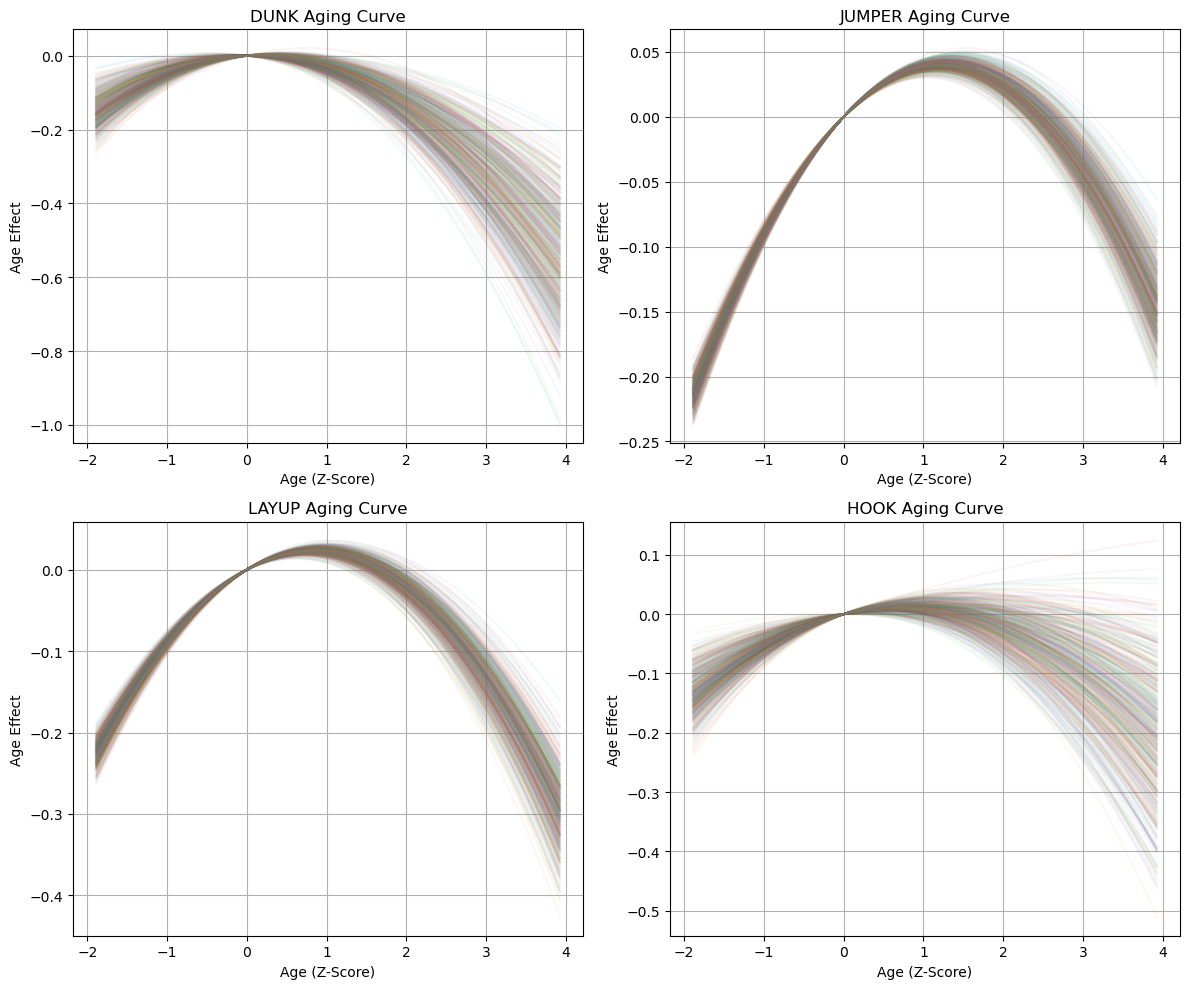

In [21]:
age_grid = np.linspace(age_z_vals.min(), age_z_vals.max(), 100)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, shot_type in zip(axes.flat, shot_type_lookup.keys()):
    plot_quad_aging_curve(trace_quad, age_grid, shot_type, shot_type_lookup, ax)

plt.tight_layout()
plt.show()

In [22]:
age_z_vals = df['age_z'].values
age_stack_vals = np.column_stack([age_z_vals**2, age_z_vals])

# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_z_vals), np.max(age_z_vals)],
    lengthscale_range=[2.5, 3.5],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 7, c: 3.85


In [23]:
coords = {
    "obs_id": np.arange(len(target)),
    "shot_type":shot_type_lookup.keys(),
    "shot_type_": shot_type_lookup.keys(),
    "player": player_lookup.keys(),
    "season": season_list,
    }
n_shot_types = len(shot_type_lookup.keys())
n_seasons = len(coords["season"])

with pm.Model(coords=coords) as model_gp:
    shots_made = pm.Data("shots_made", target, dims=("obs_id",))
    offset_data = pm.Data("offset_data", offset_vals, dims=("obs_id",))
    attempts_data = pm.Data("attempts_data", attempts_vals, dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("obs_id",))
    season_idx = pm.Data("season_idx", season_idx_vals, dims=("obs_id",))
    shot_type_idx = pm.Data("shot_type_idx", shot_type_idx_vals, dims=("obs_id",))
    age_stack_data = pm.Data("age_stack_data", age_stack_vals)

    # baseline
    offset_weight = pm.Normal("offset_weight", mu=0.2, sigma=0.2, dims=("shot_type",))
    shot_type_intercept = pm.Normal("shot_type_intercept", mu=0, sigma=1, dims=("shot_type",))
    # career skill
    chol, corr, stds = pm.LKJCholeskyCov("chol_shot_type", n=n_shot_types, eta=2.0, sd_dist=pm.HalfNormal.dist(0.25))
    pm.Deterministic("shot_type_corr", corr, dims=("shot_type", "shot_type_"))
    mu = pm.MvNormal("mu", mu=pt.zeros(n_shot_types), chol=chol, dims=("player", "shot_type"))
    # seasonal component
    sigma_dev = pm.HalfNormal("sigma_dev", 0.25, dims="shot_type") # season deviation
    delta_raw = pm.ZeroSumNormal(
        "delta_raw",
        sigma=1.0,
        dims=("player", "shot_type", "season"),
        n_zerosum_axes=1
    )
    delta = pm.Deterministic(
        "delta",
        delta_raw * sigma_dev[None, :, None],
        dims=("player", "shot_type", "season")
    )
    skill_obs = mu[player_idx, shot_type_idx] + delta[player_idx, shot_type_idx, season_idx]
    # age
    # priors
    a = pm.Normal("a", mu=-0.05, sigma=0.02, dims="shot_type")
    b = pm.Normal("b", mu=0.05, sigma=0.02, dims="shot_type")
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.1, dims="shot_type")
    ls = pm.InverseGamma("ls", alpha=3.0, beta=6.0, dims="shot_type")
    # HSGP
    f_list = []
    for s in range(n_shot_types):
        mean = pm.gp.mean.Linear(coeffs=pt.stack([a[s], b[s]]), intercept=0)
        cov_func = eta[s]**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls[s])
        gp = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
        f_list.append(gp.prior(f"f_{s}", X=age_stack_data))

    f = pm.Deterministic("f", pt.stack(f_list, axis=1), dims=("obs_id", "shot_type"))
    f_obs = f[pt.arange(f.shape[0]), shot_type_idx]
    
    theta = (
        offset_weight[shot_type_idx] * offset_data
        + shot_type_intercept[shot_type_idx]
        + skill_obs
        + f_obs
    )
    pm.Binomial("obs", n=attempts_data, p=pm.math.sigmoid(theta), observed=shots_made)

Sampling: [a, b, eta, f_0_hsgp_coeffs, f_1_hsgp_coeffs, f_2_hsgp_coeffs, f_3_hsgp_coeffs, ls]


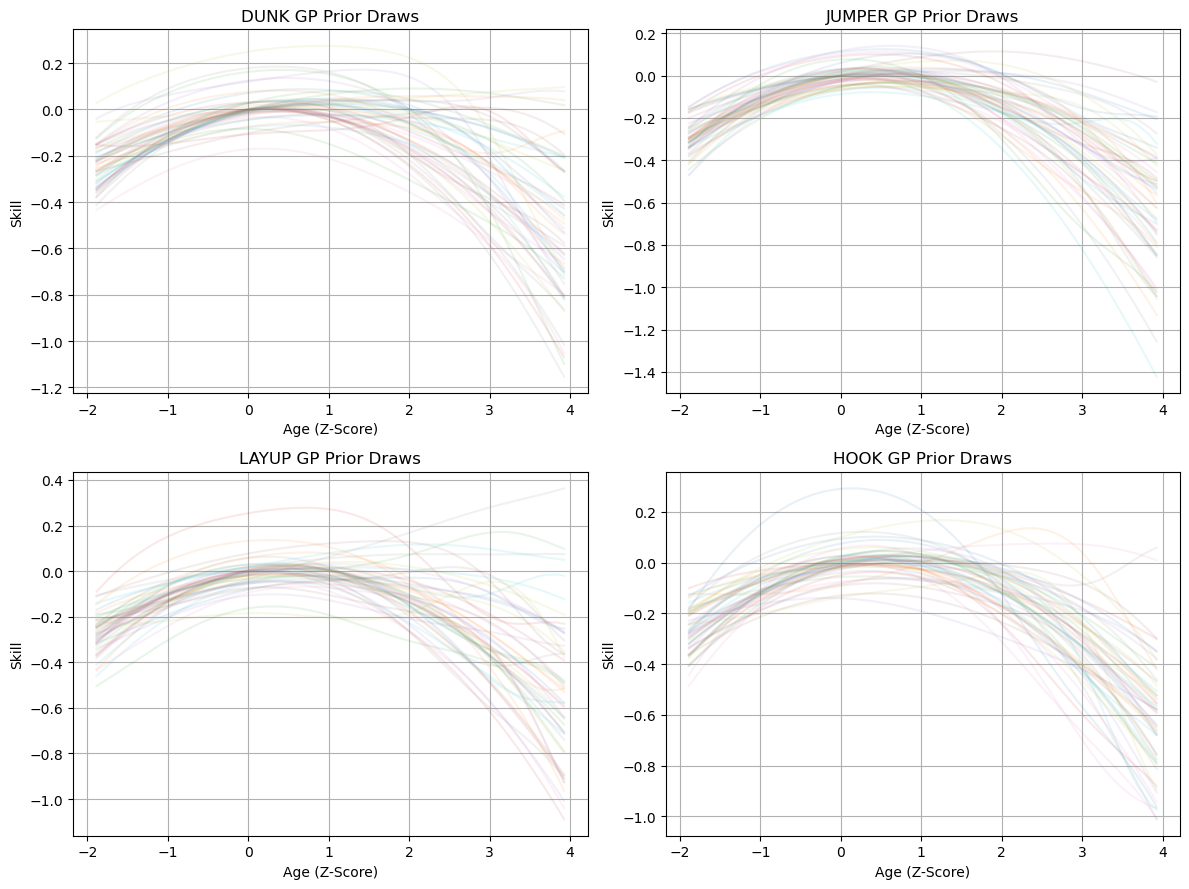

In [24]:
with model_gp:
    prior_samples = pm.sample_prior_predictive(var_names=["eta", "ls", "f"], random_seed=RANDOM_SEED, draws=50)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
rng = np.random.default_rng(RANDOM_SEED)
sort_idx = np.argsort(age_z_vals)
shot_types = shot_type_lookup.keys()
for s, (ax, shot_type) in enumerate(zip(axes.flat, shot_types)):
    gp_draws = prior_samples.prior["f"].values[..., :, s].reshape(-1, len(age_z_vals))
    draw_idx = rng.choice(gp_draws.shape[0], size=min(100, gp_draws.shape[0]), replace=False)
    for draw in gp_draws[draw_idx]:
        ax.plot(age_z_vals[sort_idx], draw[sort_idx], alpha=0.1)
    ax.set_title(f"{shot_type} GP Prior Draws")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Skill")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [25]:
trace_gp = sample(model_gp, tune=1000, draws=1000, target_accept=0.99, dense_mass=True, path='trace_gp.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [29]:
azs.summary(trace_gp, var_names=['eta', 'ls', "offset_weight", "shot_type_intercept", "shot_type_corr"], ci_prob=0.95, round_to=2)

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta[DUNK],0.07,0.06,0.00,0.21,2287.92,1938.51,1.00,0.00,0.00
eta[JUMPER],0.05,0.04,0.00,0.15,1134.67,1105.07,1.00,0.00,0.00
eta[LAYUP],0.07,0.05,0.00,0.20,1327.54,1318.42,1.00,0.00,0.00
eta[HOOK],0.07,0.05,0.00,0.20,1630.69,1635.22,1.00,0.00,0.00
ls[DUNK],2.92,2.63,0.83,9.41,4386.99,2231.81,1.00,0.05,0.27
ls[JUMPER],3.06,2.85,0.82,10.70,3120.94,1993.22,1.00,0.07,0.19
ls[LAYUP],2.88,2.64,0.81,9.03,4154.41,2281.47,1.00,0.06,0.24
ls[HOOK],3.01,2.85,0.85,10.29,3126.03,1606.59,1.00,0.08,0.29
offset_weight[DUNK],0.35,0.03,0.29,0.41,2278.79,2454.21,1.00,0.00,0.00
offset_weight[JUMPER],0.35,0.04,0.27,0.44,833.38,1390.22,1.00,0.00,0.00


In [15]:
def plot_gp_aging_curves(trace, age_data, shot_types, n_draws=100):
    age = np.asarray(age_data).reshape(-1)
    sort_idx = np.argsort(age)
    age_sorted = age[sort_idx]
    _, axes = plt.subplots(2, 2, figsize=(12, 9))
    for s, (ax, shot_type) in enumerate(zip(axes.flat, shot_types)):
        f = trace.posterior["f"].values[..., :, s].reshape(-1, len(age))
        f = f[:, sort_idx]
        mean = f.mean(axis=0)
        lower, upper = np.quantile(f, [0.025, 0.975], axis=0)
        ax.plot(age_sorted, mean, linewidth=2)
        ax.fill_between(age_sorted, lower, upper, alpha=0.2)

        ax.set_title(f"{shot_type} GP Aging Curve")
        ax.set_xlabel("Age (Z-Score)")
        ax.set_ylabel("Skill")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

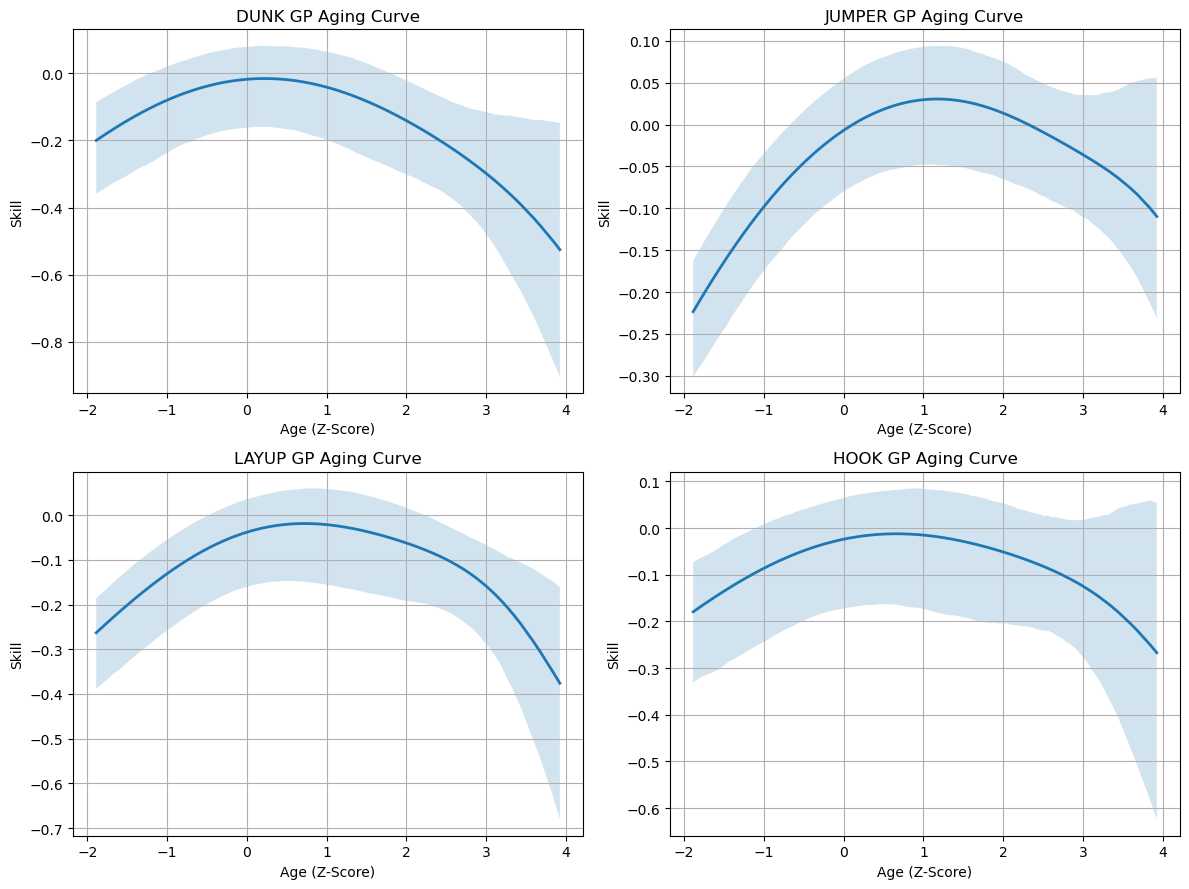

In [36]:
plot_gp_aging_curves(trace_gp, age_z_vals, shot_type_lookup.keys())

In [12]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_z_vals), np.max(age_z_vals)],
    lengthscale_range=[0.5, 1.5],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

age_z_vals = df['age_z'].values
age_stack_vals = np.column_stack([age_z_vals**2, age_z_vals])

m: 16, c: 1.65


In [19]:
coords = {
    "obs_id": np.arange(len(target)),
    "shot_type":shot_type_lookup.keys(),
    "shot_type_": shot_type_lookup.keys(),
    "player": player_lookup.keys(),
    "season": season_list,
    }
n_shot_types = len(shot_type_lookup.keys())
n_seasons = len(coords["season"])

with pm.Model(coords=coords) as model_gp_v2:
    shots_made = pm.Data("shots_made", target, dims=("obs_id",))
    offset_data = pm.Data("offset_data", offset_vals, dims=("obs_id",))
    attempts_data = pm.Data("attempts_data", attempts_vals, dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("obs_id",))
    season_idx = pm.Data("season_idx", season_idx_vals, dims=("obs_id",))
    shot_type_idx = pm.Data("shot_type_idx", shot_type_idx_vals, dims=("obs_id",))
    age_stack_data = pm.Data("age_stack_data", age_stack_vals)

    # baseline
    offset_weight = pm.Normal("offset_weight", mu=0.2, sigma=0.2, dims=("shot_type",))
    shot_type_intercept = pm.Normal("shot_type_intercept", mu=0, sigma=1, dims=("shot_type",))
    # career skill
    chol, corr, stds = pm.LKJCholeskyCov("chol_shot_type", n=n_shot_types, eta=2.0, sd_dist=pm.HalfNormal.dist(0.25))
    pm.Deterministic("shot_type_corr", corr, dims=("shot_type", "shot_type_"))
    mu = pm.MvNormal("mu", mu=pt.zeros(n_shot_types), chol=chol, dims=("player", "shot_type"))
    # seasonal component
    sigma_dev = pm.HalfNormal("sigma_dev", 0.25, dims="shot_type") # season deviation
    delta_raw = pm.ZeroSumNormal(
        "delta_raw",
        sigma=1.0,
        dims=("player", "shot_type", "season"),
        n_zerosum_axes=1
    )
    delta = pm.Deterministic(
        "delta",
        delta_raw * sigma_dev[None, :, None],
        dims=("player", "shot_type", "season")
    )
    skill_obs = mu[player_idx, shot_type_idx] + delta[player_idx, shot_type_idx, season_idx]
    # age
    # priors
    a = pm.Normal("a", mu=-0.05, sigma=0.02, dims="shot_type")
    b = pm.Normal("b", mu=0.05, sigma=0.02, dims="shot_type")
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.2, dims="shot_type")
    ls = pm.InverseGamma("ls", alpha=7.0, beta=6.0, dims="shot_type")
    # HSGP
    f_list = []
    for s in range(n_shot_types):
        mean = pm.gp.mean.Linear(coeffs=pt.stack([a[s], b[s]]), intercept=0)
        cov_func = eta[s]**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls[s])
        gp = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
        f_list.append(gp.prior(f"f_{s}", X=age_stack_data))

    f = pm.Deterministic("f", pt.stack(f_list, axis=1), dims=("obs_id", "shot_type"))
    f_obs = f[pt.arange(f.shape[0]), shot_type_idx]
    
    theta = (
        offset_weight[shot_type_idx] * offset_data
        + shot_type_intercept[shot_type_idx]
        + skill_obs
        + f_obs
    )
    pm.Binomial("obs", n=attempts_data, p=pm.math.sigmoid(theta), observed=shots_made)

Sampling: [a, b, eta, f_0_hsgp_coeffs, f_1_hsgp_coeffs, f_2_hsgp_coeffs, f_3_hsgp_coeffs, ls]


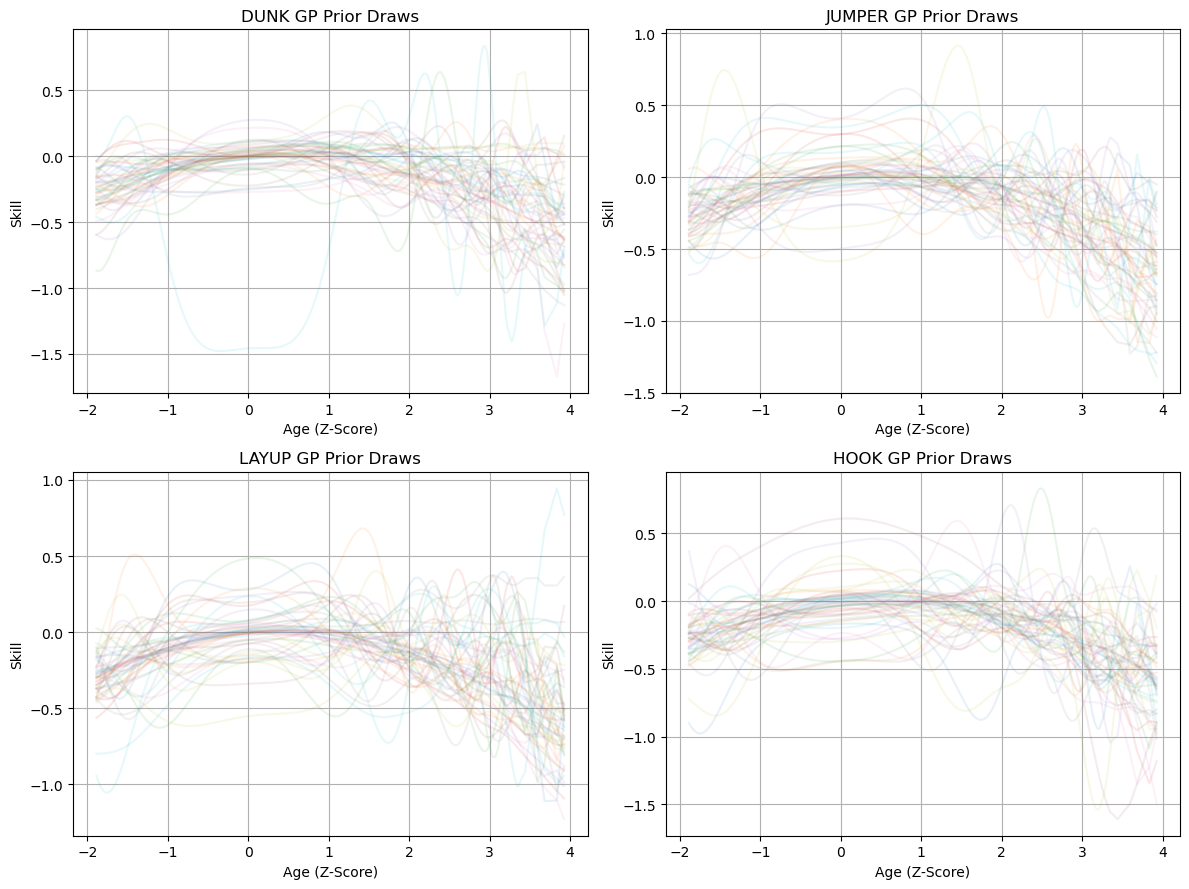

In [20]:
with model_gp_v2:
    prior_samples = pm.sample_prior_predictive(var_names=["eta", "ls", "f"], random_seed=RANDOM_SEED, draws=50)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
rng = np.random.default_rng(RANDOM_SEED)
sort_idx = np.argsort(age_z_vals)
shot_types = shot_type_lookup.keys()
for s, (ax, shot_type) in enumerate(zip(axes.flat, shot_types)):
    gp_draws = prior_samples.prior["f"].values[..., :, s].reshape(-1, len(age_z_vals))
    draw_idx = rng.choice(gp_draws.shape[0], size=min(100, gp_draws.shape[0]), replace=False)
    for draw in gp_draws[draw_idx]:
        ax.plot(age_z_vals[sort_idx], draw[sort_idx], alpha=0.1)
    ax.set_title(f"{shot_type} GP Prior Draws")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Skill")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [21]:
trace_gp_v2 = sample(model_gp_v2, tune=1000, draws=1000, target_accept=0.99, dense_mass=True, path='trace_gp_v2.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [22]:
azs.summary(trace_gp_v2, var_names=['eta', 'ls', "offset_weight", "shot_type_intercept", "shot_type_corr"], ci_prob=0.95, round_to=2)

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta[DUNK],0.04,0.04,0.00,0.14,1930.89,2229.50,1.00,0.00,0.00
eta[JUMPER],0.01,0.01,0.00,0.03,1310.99,2049.55,1.00,0.00,0.00
eta[LAYUP],0.03,0.02,0.00,0.08,831.30,1105.97,1.00,0.00,0.00
eta[HOOK],0.04,0.04,0.00,0.17,836.17,927.85,1.00,0.00,0.00
ls[DUNK],1.07,0.52,0.46,2.41,4518.66,2787.10,1.00,0.01,0.02
ls[JUMPER],1.11,0.62,0.47,2.63,4476.87,2420.68,1.00,0.01,0.04
ls[LAYUP],1.09,0.53,0.47,2.41,2497.35,1531.84,1.00,0.01,0.02
ls[HOOK],1.07,0.53,0.46,2.45,3778.29,2093.30,1.00,0.01,0.02
offset_weight[DUNK],0.35,0.03,0.29,0.41,2841.64,2863.73,1.00,0.00,0.00
offset_weight[JUMPER],0.35,0.04,0.27,0.43,853.39,1310.69,1.00,0.00,0.00


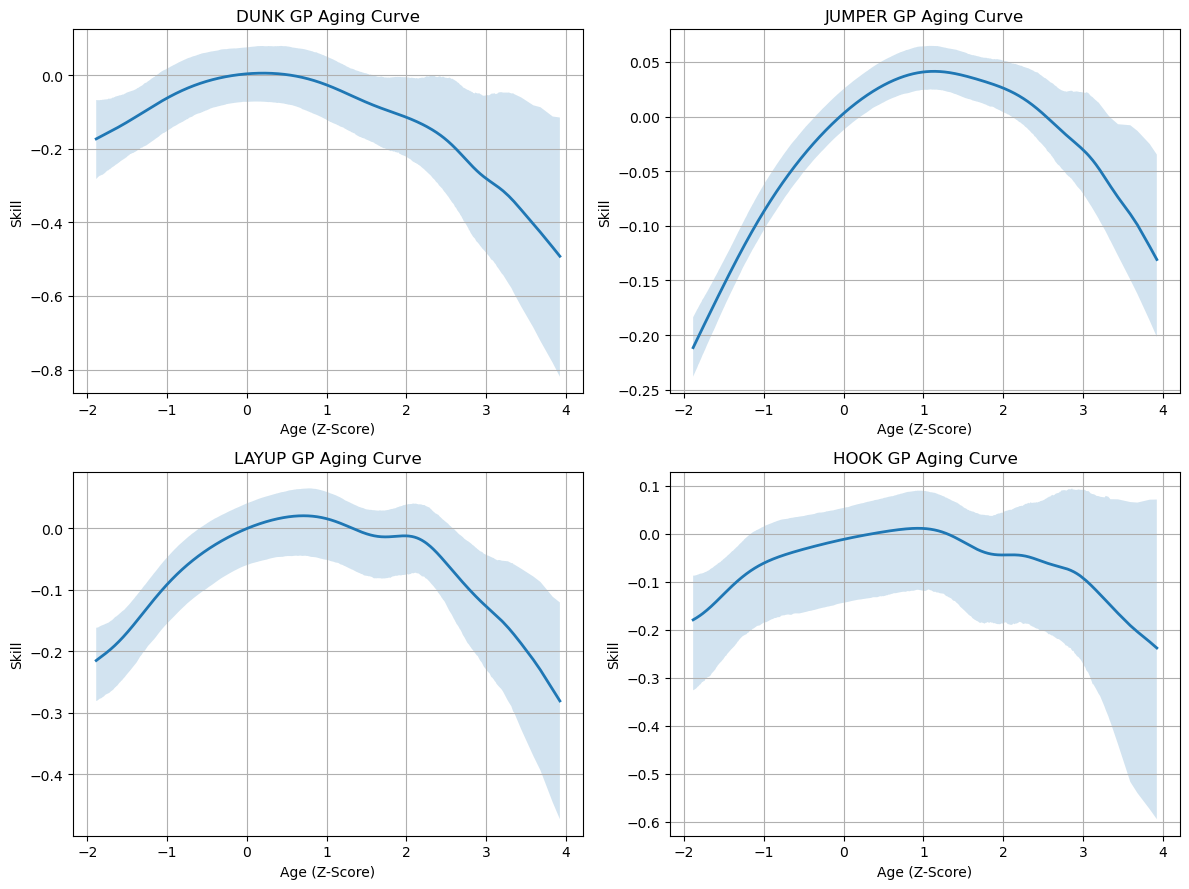

In [24]:
plot_gp_aging_curves(trace_gp_v2, age_z_vals, shot_type_lookup.keys())

In [10]:
age_z_vals = df['age_z'].values
age_stack_vals = np.column_stack([age_z_vals**2, age_z_vals])

# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_z_vals), np.max(age_z_vals)],
    lengthscale_range=[1.5, 2.5],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 9, c: 2.75


In [11]:
coords = {
    "obs_id": np.arange(len(target)),
    "shot_type":shot_type_lookup.keys(),
    "shot_type_": shot_type_lookup.keys(),
    "player": player_lookup.keys(),
    "season": season_list,
    }
n_shot_types = len(shot_type_lookup.keys())
n_seasons = len(coords["season"])

with pm.Model(coords=coords) as model_gp_v3:
    shots_made = pm.Data("shots_made", target, dims=("obs_id",))
    offset_data = pm.Data("offset_data", offset_vals, dims=("obs_id",))
    attempts_data = pm.Data("attempts_data", attempts_vals, dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("obs_id",))
    season_idx = pm.Data("season_idx", season_idx_vals, dims=("obs_id",))
    shot_type_idx = pm.Data("shot_type_idx", shot_type_idx_vals, dims=("obs_id",))
    age_stack_data = pm.Data("age_stack_data", age_stack_vals)

    # baseline
    offset_weight = pm.Normal("offset_weight", mu=0.2, sigma=0.2, dims=("shot_type",))
    shot_type_intercept = pm.Normal("shot_type_intercept", mu=0, sigma=1, dims=("shot_type",))
    # career skill
    chol, corr, stds = pm.LKJCholeskyCov("chol_shot_type", n=n_shot_types, eta=2.0, sd_dist=pm.HalfNormal.dist(0.25))
    pm.Deterministic("shot_type_corr", corr, dims=("shot_type", "shot_type_"))
    mu = pm.MvNormal("mu", mu=pt.zeros(n_shot_types), chol=chol, dims=("player", "shot_type"))
    # seasonal component
    sigma_dev = pm.HalfNormal("sigma_dev", 0.25, dims="shot_type") # season deviation
    delta_raw = pm.ZeroSumNormal(
        "delta_raw",
        sigma=1.0,
        dims=("player", "shot_type", "season"),
        n_zerosum_axes=1
    )
    delta = pm.Deterministic(
        "delta",
        delta_raw * sigma_dev[None, :, None],
        dims=("player", "shot_type", "season")
    )
    skill_obs = mu[player_idx, shot_type_idx] + delta[player_idx, shot_type_idx, season_idx]
    # age
    # priors
    a = pm.Normal("a", mu=-0.05, sigma=0.02, dims="shot_type")
    b = pm.Normal("b", mu=0.05, sigma=0.02, dims="shot_type")
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.2, dims="shot_type")
    ls = pm.InverseGamma("ls", alpha=2.5, beta=5.0, dims="shot_type")
    # HSGP
    f_list = []
    for s in range(n_shot_types):
        mean = pm.gp.mean.Linear(coeffs=pt.stack([a[s], b[s]]), intercept=0)
        cov_func = eta[s]**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls[s])
        gp = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
        f_list.append(gp.prior(f"f_{s}", X=age_stack_data))

    f = pm.Deterministic("f", pt.stack(f_list, axis=1), dims=("obs_id", "shot_type"))
    f_obs = f[pt.arange(f.shape[0]), shot_type_idx]
    
    theta = (
        offset_weight[shot_type_idx] * offset_data
        + shot_type_intercept[shot_type_idx]
        + skill_obs
        + f_obs
    )
    pm.Binomial("obs", n=attempts_data, p=pm.math.sigmoid(theta), observed=shots_made)

Sampling: [a, b, eta, f_0_hsgp_coeffs, f_1_hsgp_coeffs, f_2_hsgp_coeffs, f_3_hsgp_coeffs, ls]


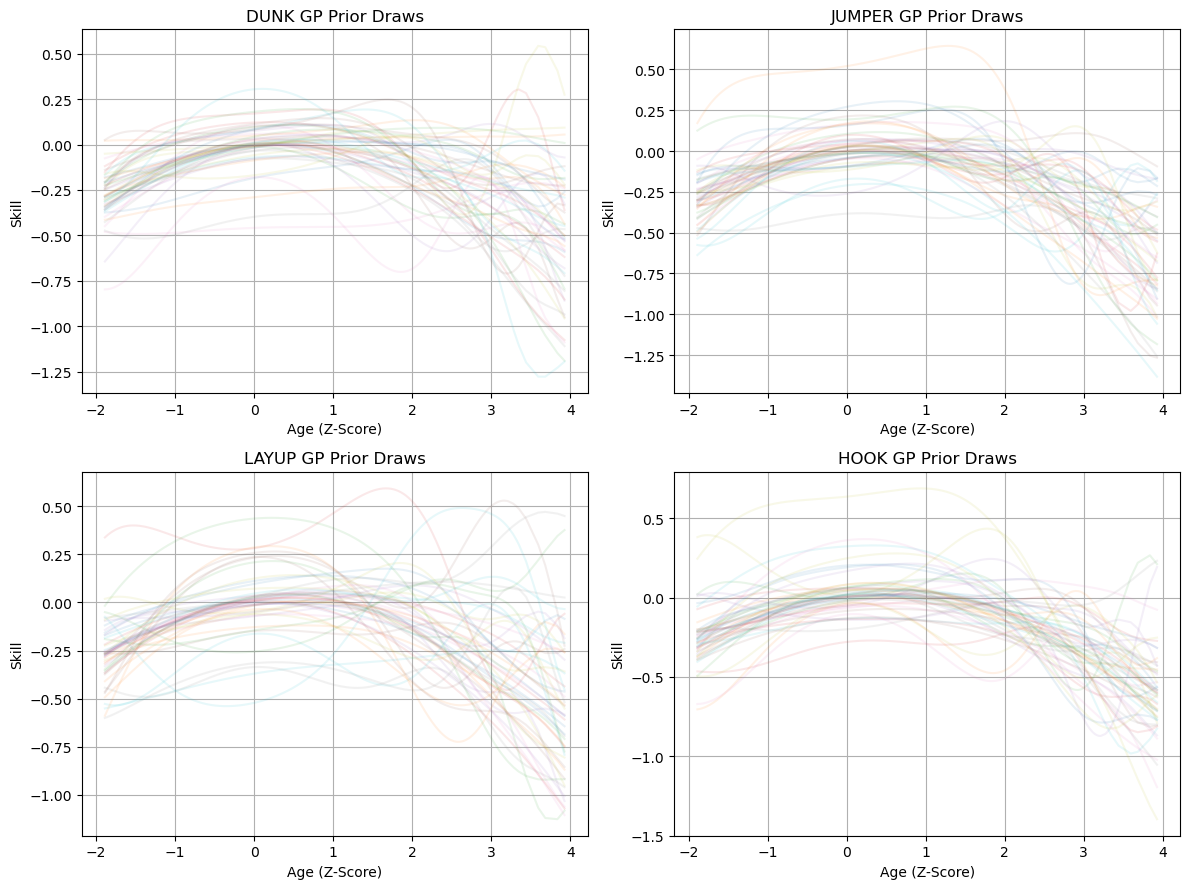

In [12]:
with model_gp_v3:
    prior_samples = pm.sample_prior_predictive(var_names=["eta", "ls", "f"], random_seed=RANDOM_SEED, draws=50)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
rng = np.random.default_rng(RANDOM_SEED)
sort_idx = np.argsort(age_z_vals)
shot_types = shot_type_lookup.keys()
for s, (ax, shot_type) in enumerate(zip(axes.flat, shot_types)):
    gp_draws = prior_samples.prior["f"].values[..., :, s].reshape(-1, len(age_z_vals))
    draw_idx = rng.choice(gp_draws.shape[0], size=min(100, gp_draws.shape[0]), replace=False)
    for draw in gp_draws[draw_idx]:
        ax.plot(age_z_vals[sort_idx], draw[sort_idx], alpha=0.1)
    ax.set_title(f"{shot_type} GP Prior Draws")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Skill")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [13]:
trace_gp_v3 = sample(model_gp_v3, tune=1000, draws=1000, target_accept=0.99, dense_mass=True, path='trace_gp_v3.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

There were 91 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [14]:
azs.summary(trace_gp_v3, var_names=['eta', 'ls', "offset_weight", "shot_type_intercept", "shot_type_corr"], ci_prob=0.95, round_to=2)

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta[DUNK],0.10,0.08,0.00,0.31,1879.25,2213.31,1.00,0.00,0.00
eta[JUMPER],0.06,0.08,0.00,0.29,1228.23,1758.94,1.00,0.00,0.00
eta[LAYUP],0.08,0.07,0.00,0.27,1602.92,1723.28,1.00,0.00,0.00
eta[HOOK],0.11,0.10,0.00,0.36,1903.02,2569.78,1.00,0.00,0.00
ls[DUNK],3.66,3.68,0.82,13.56,4168.88,2427.05,1.00,0.07,0.19
ls[JUMPER],5.81,5.79,0.84,21.21,1743.39,1829.57,1.00,0.16,0.29
ls[LAYUP],4.08,4.23,0.79,15.41,2651.98,2096.25,1.00,0.10,0.23
ls[HOOK],4.33,4.79,0.78,16.77,3843.93,2287.60,1.00,0.11,0.26
offset_weight[DUNK],0.35,0.03,0.29,0.41,5011.77,3473.73,1.00,0.00,0.00
offset_weight[JUMPER],0.35,0.04,0.27,0.44,1764.39,2276.24,1.00,0.00,0.00


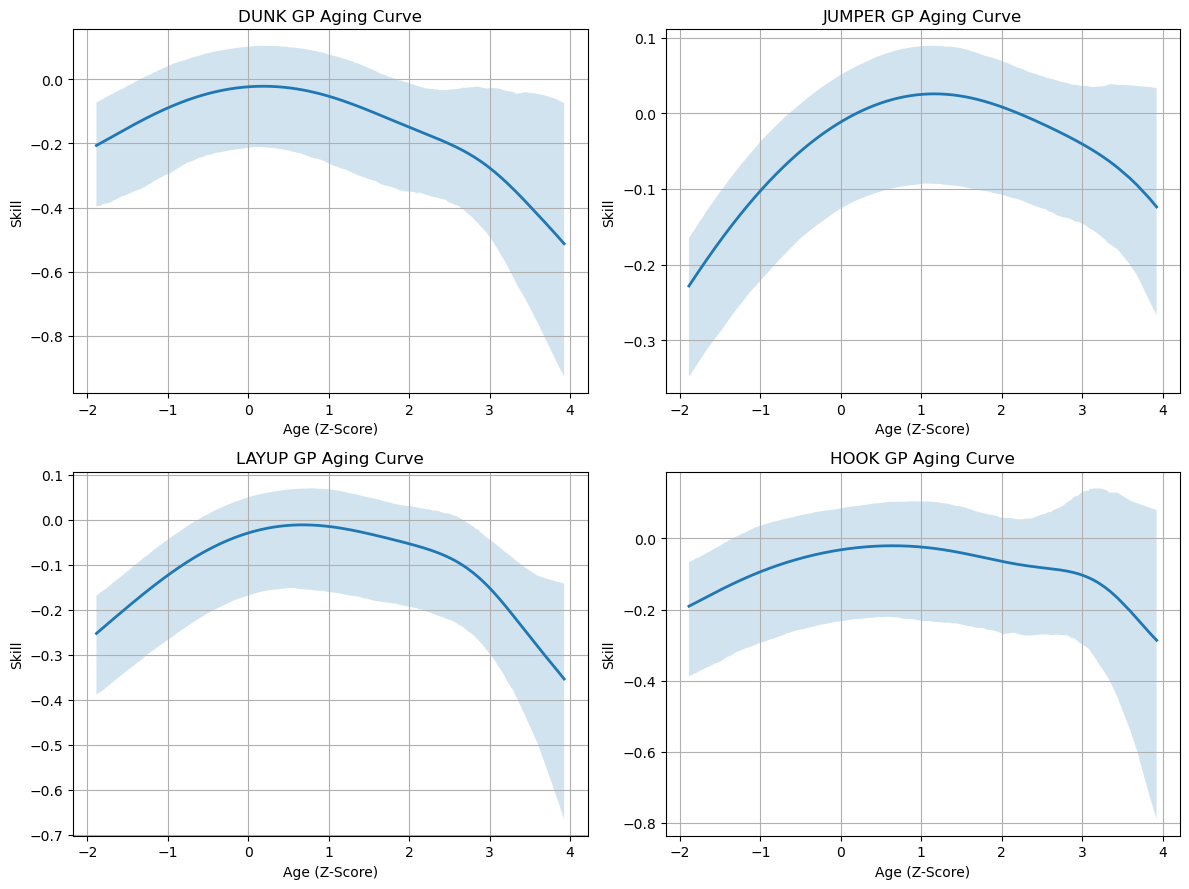

In [16]:
plot_gp_aging_curves(trace_gp_v3, age_z_vals, shot_type_lookup.keys())